In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [21]:
class BMIState(TypedDict):

    weight_kg:float
    height_m:float
    label:str
    bmi:float


In [22]:
def calculateBMI(state:BMIState)->BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    state['bmi'] = weight/(height**2)
    return state

In [18]:
def labelBMI(state:BMIState)->BMIState:
    label = ""
    if(state['bmi']>25):
        label = 'high'
    else:
        label = 'low'
    
    state['label'] = label
    print(label)
    
    return state

In [23]:
graph = StateGraph(BMIState)

graph.add_node('BMICalculator',calculateBMI)
graph.add_node('Label',labelBMI)

# add edges between the nodes
graph.add_edge(START,'BMICalculator')
graph.add_edge('BMICalculator','Label')
graph.add_edge('Label',END)

workflow = graph.compile()

In [25]:

# execute the graph
initial_state = workflow.invoke({'weight_kg':278,'height_m':2.2})

final_state = workflow.invoke(initial_state)

print(final_state)

high
high
{'weight_kg': 278, 'height_m': 2.2, 'label': 'high', 'bmi': 57.43801652892561}


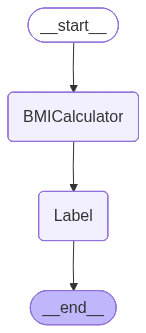

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())